# Price distributions

Quick visualization of the scaled beta gas, coal, and electricity price distributions with a sample size of 100,000.


In [1]:
from pathlib import Path
import sys

import math

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from distributions import sample_scaled_beta
from general_parameters import (
    COAL_PRICE_DISTRIBUTION,
    ELECTRICITY_PRICE_DISTRIBUTION,
    GAS_PRICE_DISTRIBUTION,
)


In [2]:
SAMPLE_SIZE = 100_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

gas_samples = sample_scaled_beta(GAS_PRICE_DISTRIBUTION, size=SAMPLE_SIZE, rng=rng)
coal_samples = sample_scaled_beta(COAL_PRICE_DISTRIBUTION, size=SAMPLE_SIZE, rng=rng)
electricity_samples = sample_scaled_beta(
    ELECTRICITY_PRICE_DISTRIBUTION,
    size=SAMPLE_SIZE,
    rng=rng,
)


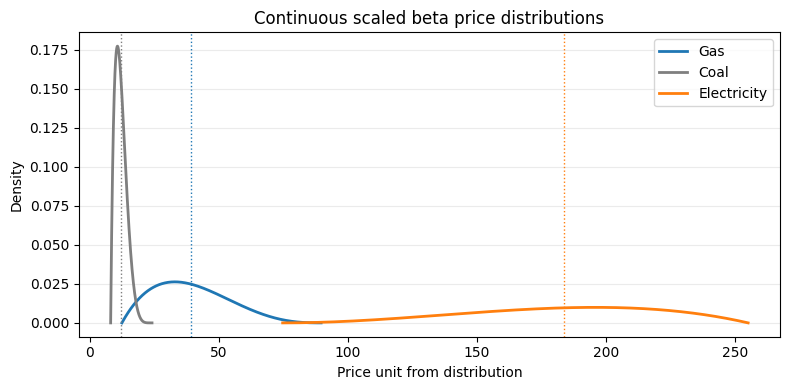

In [3]:
def scaled_beta_pdf(x, distribution):
    minimum = distribution.minimum
    maximum = distribution.maximum
    normalized_x = (x - minimum) / (maximum - minimum)

    pdf = np.zeros_like(x, dtype=float)
    inside = (0 < normalized_x) & (normalized_x < 1)

    beta_function = math.exp(
        math.lgamma(distribution.alpha)
        + math.lgamma(distribution.beta)
        - math.lgamma(distribution.alpha + distribution.beta)
    )
    pdf[inside] = (
        normalized_x[inside] ** (distribution.alpha - 1)
        * (1 - normalized_x[inside]) ** (distribution.beta - 1)
        / beta_function
        / (maximum - minimum)
    )
    return pdf


fig, ax = plt.subplots(figsize=(8, 4))

for label, distribution, color in [
    ("Gas", GAS_PRICE_DISTRIBUTION, "tab:blue"),
    ("Coal", COAL_PRICE_DISTRIBUTION, "tab:gray"),
    ("Electricity", ELECTRICITY_PRICE_DISTRIBUTION, "tab:orange"),
]:
    x = np.linspace(distribution.minimum, distribution.maximum, 500)
    ax.plot(x, scaled_beta_pdf(x, distribution), label=label, color=color, linewidth=2)
    ax.axvline(distribution.mean, color=color, linestyle=":", linewidth=1)

ax.set_title("Continuous scaled beta price distributions")
ax.set_xlabel("Price unit from distribution")
ax.set_ylabel("Density")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


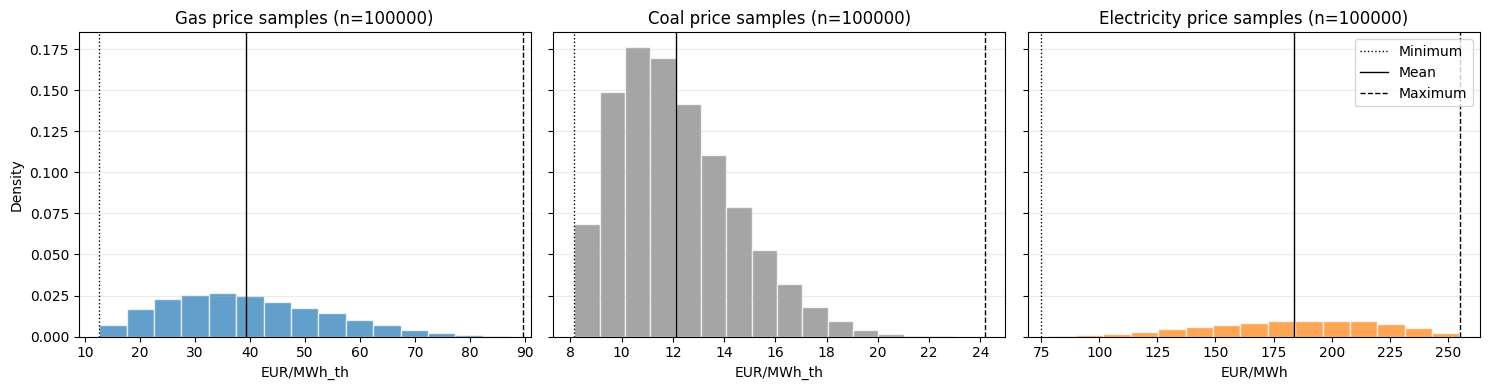

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

plots = [
    ("Gas", gas_samples, GAS_PRICE_DISTRIBUTION, "tab:blue"),
    ("Coal", coal_samples, COAL_PRICE_DISTRIBUTION, "tab:gray"),
    ("Electricity", electricity_samples, ELECTRICITY_PRICE_DISTRIBUTION, "tab:orange"),
]

for ax, (label, samples, distribution, color) in zip(axes, plots):
    ax.hist(samples, bins=15, density=True, alpha=0.7, color=color, edgecolor="white")
    ax.axvline(distribution.minimum, color="black", linestyle=":", linewidth=1, label="Minimum")
    ax.axvline(distribution.mean, color="black", linestyle="-", linewidth=1, label="Mean")
    ax.axvline(distribution.maximum, color="black", linestyle="--", linewidth=1, label="Maximum")
    ax.set_title(f"{label} price samples (n={SAMPLE_SIZE})")
    ax.set_xlabel(distribution.unit)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Density")
axes[-1].legend(loc="upper right")
fig.tight_layout()
plt.show()


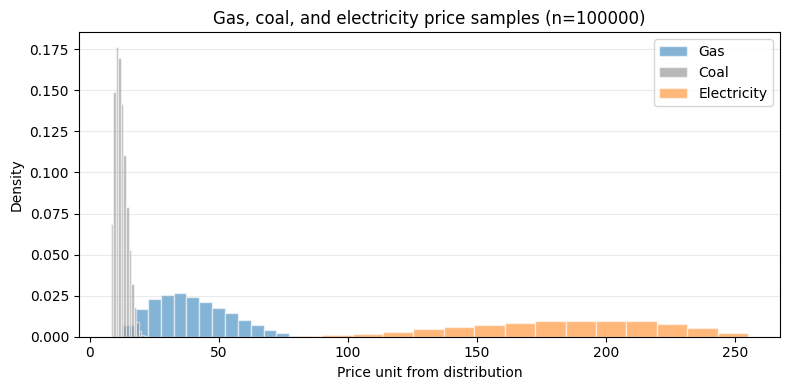

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(gas_samples, bins=15, density=True, alpha=0.55, label="Gas", color="tab:blue", edgecolor="white")
ax.hist(coal_samples, bins=15, density=True, alpha=0.55, label="Coal", color="tab:gray", edgecolor="white")
ax.hist(
    electricity_samples,
    bins=15,
    density=True,
    alpha=0.55,
    label="Electricity",
    color="tab:orange",
    edgecolor="white",
)
ax.set_title(f"Gas, coal, and electricity price samples (n={SAMPLE_SIZE})")
ax.set_xlabel("Price unit from distribution")
ax.set_ylabel("Density")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()
